In [30]:
# Instalación de dependencias (solo necesario en Colab)
!pip install -q shap

# Fase 3: Causas Raíz - Modelo ML Explicable
## Prueba Técnica - Análisis de Quejas ARL SURA

**Objetivo:** Construir un modelo explicable que identifique y cuantifique las causas raíz de insatisfacción.

**Enfoque:**
- Variable Y (proxy de insatisfacción): escalamiento a Entes de Control + recurrencia
- Modelos ML explicables: Regresión Logística, Random Forest, XGBoost
- SHAP values para cuantificar contribución de cada factor
- Identificación de patrones en quejas graves vs leves

---
### Estructura del notebook
0. **Configuración inicial (Google Colab)**
1. Carga de datos con features NLP (del notebook 02)
2. Definición de variable objetivo (Y)
3. Ingeniería de features adicionales
4. Entrenamiento de modelos ML
5. Interpretabilidad con SHAP
6. Análisis de causas raíz por segmento
7. Recomendaciones accionables

---

## ⚡ CONFIGURACIÓN PARA GOOGLE COLAB

**IMPORTANTE:** Este notebook está optimizado para ejecutarse en **Google Colab con GPU**.

### Requisitos:
- Haber ejecutado el **Notebook 02** previamente (genera `quejas_con_features_nlp.csv`)
- Datos en Google Drive en `MyDrive/sura/data/`

In [31]:
import sys, os
from pathlib import Path

EN_COLAB = 'google.colab' in sys.modules

if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # ── AJUSTA SI TU EXCEL ESTÁ EN OTRA RUTA DE DRIVE ─────────────────────────
    DATA_FILE = Path('/content/drive/MyDrive/sura/quejas_con_features_nlp.csv')
    # ──────────────────────────────────────────────────────────────────────────

    OUT_BASE      = Path('/content/drive/MyDrive/sura')
    IMAGES_DIR    = OUT_BASE / 'resume' / 'images'
    MODELS_DIR    = OUT_BASE / 'src'
    DASHBOARD_DIR = OUT_BASE / 'dashboard' / 'public' / 'data'
    print('Entorno: Google Colab')
else:
    BASE_DIR      = Path('..').resolve()
    DATA_FILE     = BASE_DIR / 'data/quejas_con_features_nlp.csv'
    IMAGES_DIR    = BASE_DIR / 'resume' / 'images'
    MODELS_DIR    = BASE_DIR / 'src'
    DASHBOARD_DIR = BASE_DIR / 'dashboard' / 'public' / 'data'
    print('Entorno: local')

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

print(f'DATA_FILE : {DATA_FILE}  →  existe={DATA_FILE.exists()}')
print(f'Imágenes  : {IMAGES_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Google Colab
DATA_FILE : /content/drive/MyDrive/sura/quejas_con_features_nlp.csv  →  existe=True
Imágenes  : /content/drive/MyDrive/sura/resume/images


In [32]:
import os
from google.colab import drive

# Forzamos el montaje con un método que VS Code suele entender mejor
if EN_COLAB:
    print("Iniciando montaje de Drive...")
    try:
        # Intentamos el montaje estándar
        drive.mount('/content/drive', force_remount=True)
    except Exception as e:
        print(f"Error automático: {e}")
        print("Copia y pega el enlace que aparezca abajo (si aparece) o abre el notebook en el navegador una vez.")

    BASE_DIR = '/content/drive/MyDrive/sura'
    DATA_FILE = f'{BASE_DIR}/quejas_con_features_nlp.csv'

    if os.path.exists(DATA_FILE):
        print(f"✅ Archivo encontrado: {DATA_FILE}")
    else:
        print(f"❌ Archivo NO encontrado en: {DATA_FILE}")
        # Tip: Lista lo que hay en MyDrive para ver si la ruta está bien escrita
        if os.path.exists('/content/drive/MyDrive'):
            print("Contenido de MyDrive:", os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
✅ Archivo encontrado: /content/drive/MyDrive/sura/quejas_con_features_nlp.csv


---
## 0. Librerías

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score
)

# Interpretabilidad
import shap

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")
sns.set_palette("tab10")
pd.set_option('display.max_colwidth', 80)

print("Librerías cargadas ✓")

Librerías cargadas ✓


In [34]:
# Instalar SHAP si no está disponible
try:
    import shap
    print("✓ SHAP ya está instalado")
except ImportError:
    print("Instalando SHAP...")
    !pip install shap -q
    import shap
    print("✓ SHAP instalado exitosamente")

✓ SHAP ya está instalado


---
## 1. Carga de datos con features NLP

In [35]:
print(f"Cargando datos desde: {DATA_FILE}")

df = pd.read_csv(DATA_FILE)

print(f"\nRegistros: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nPrimeras columnas:")
print(df.columns[:20].tolist())

df.head(3)

Cargando datos desde: /content/drive/MyDrive/sura/quejas_con_features_nlp.csv

Registros: 1,836
Columnas: 35

Primeras columnas:
['mes_apertura', 'descripcion', 'tipo', 'cliente', 'canal', 'fecha', 'mes_nombre', 'len_descripcion', 'cliente_norm', 'es_recurrente', 'escalado_entes', 'texto_limpio', 'n_tokens', 'topic_lda', 'topic_lda_prob', 'tiene_pago', 'tiene_incapacidad', 'tiene_radicacion', 'tiene_transcurso', 'tiene_respuesta']


,mes_apertura,descripcion,tipo,cliente,canal,fecha,mes_nombre,len_descripcion,cliente_norm,es_recurrente,...,tiene_tutela,tiene_derecho_peticion,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7
0,202501,USUARIA SOLICITA SABER EL ESTADO DE UNA INCAPACIDAD,QUEJA,JORGE MEJIA,LINEA DE ATENCIÓN,2025-01-01,Jan 2025,51,JORGE MEJIA,False,...,0,0,True,False,False,False,False,False,False,False
1,202501,BUEN DÍA CANDIALMENTE SOLICITAMOS INFORMACIÓN SOBRE EL ESTADO DE LA INCAPACI...,QUEJA,FERLEY GANAN,SEGUROSSURA.COM.CO,2025-01-01,Jan 2025,404,FERLEY GANAN,True,...,0,0,False,True,False,False,False,False,False,False
2,202501,"BUENAS DÍAS , QUIERO UN CERTIFICADO DE INCAPACIDADES Q VALLA DIRIGIDA A LA C...",QUEJA,FABIAN LOPEZ,SEGUROSSURA.COM.CO,2025-01-01,Jan 2025,594,FABIAN LOPEZ,False,...,0,0,False,False,False,False,False,True,False,False


In [36]:
# Identificar tipos de features
feature_tiene = [col for col in df.columns if col.startswith('tiene_')]
feature_topic = [col for col in df.columns if col.startswith('topic_')]

print(f"Features de términos clave ({len(feature_tiene)}):")
print(feature_tiene)
print(f"\nFeatures de tópicos ({len(feature_topic)}):")
print(feature_topic)
print(f"\nOtras columnas relevantes:")
print([col for col in df.columns if col in ['es_recurrente', 'escalado_entes', 'canal', 'len_descripcion', 'n_tokens']])

Features de términos clave (12):
['tiene_pago', 'tiene_incapacidad', 'tiene_radicacion', 'tiene_transcurso', 'tiene_respuesta', 'tiene_tramite', 'tiene_estado', 'tiene_tiempo', 'tiene_certificado', 'tiene_subsanacion', 'tiene_tutela', 'tiene_derecho_peticion']

Features de tópicos (10):
['topic_lda', 'topic_lda_prob', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7']

Otras columnas relevantes:
['canal', 'len_descripcion', 'es_recurrente', 'escalado_entes', 'n_tokens']


---
## 2. Definición de variable objetivo (Y)

Creamos una variable **proxy de insatisfacción grave** basada en:
1. **Escalamiento a Entes de Control** (peso alto): indica insatisfacción crítica
2. **Recurrencia del cliente** (peso medio): múltiples quejas = problemas no resueltos
3. **Combinación:** quejas escaladas O clientes muy recurrentes (≥3 quejas)

In [37]:
# --- 2.1 Análisis de distribución base ---
print("Distribución de variables proxy:")
print(f"\nEscalado a Entes de Control:")
print(df['escalado_entes'].value_counts())
print(f"\nEs recurrente (>1 queja):")
print(df['es_recurrente'].value_counts())

# Contar quejas por cliente
freq_cliente = df.groupby('cliente_norm').size().reset_index(name='n_quejas_cliente')
df = df.merge(freq_cliente, on='cliente_norm', how='left')

print(f"\nDistribución de número de quejas por cliente:")
print(df['n_quejas_cliente'].describe())

Distribución de variables proxy:

Escalado a Entes de Control:
escalado_entes
False    1679
True      157
Name: count, dtype: int64

Es recurrente (>1 queja):
es_recurrente
False    1052
True      784
Name: count, dtype: int64

Distribución de número de quejas por cliente:
count    1836.000000
mean        2.126362
std         1.932750
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        11.000000
Name: n_quejas_cliente, dtype: float64


In [38]:
# --- 2.2 Definir variable objetivo ---
# OPCIÓN A: Simple - solo escalamiento
df['y_insatisfaccion_simple'] = df['escalado_entes'].astype(int)

# OPCIÓN B: Combinada - escalamiento O muy recurrente
df['y_insatisfaccion'] = (
    (df['escalado_entes']) | 
    (df['n_quejas_cliente'] >= 3)
).astype(int)

# OPCIÓN C: Score continuo (para exploración)
df['insatisfaccion_score'] = (
    df['escalado_entes'].astype(int) * 3 +  # Peso alto
    (df['n_quejas_cliente'] >= 3).astype(int) * 2 +  # Peso medio
    (df['n_quejas_cliente'] >= 2).astype(int) * 1  # Peso bajo
)

print("="*80)
print("VARIABLES OBJETIVO CREADAS")
print("="*80)

print("\n1. y_insatisfaccion_simple (solo escalamiento):")
print(df['y_insatisfaccion_simple'].value_counts())
print(f"   Tasa de positivos: {df['y_insatisfaccion_simple'].mean()*100:.1f}%")

print("\n2. y_insatisfaccion (escalamiento O ≥3 quejas):")
print(df['y_insatisfaccion'].value_counts())
print(f"   Tasa de positivos: {df['y_insatisfaccion'].mean()*100:.1f}%")

print("\n3. insatisfaccion_score (0-6):")
print(df['insatisfaccion_score'].value_counts().sort_index())

# Usaremos la opción B como objetivo principal
print("\n" + "="*80)
print("📌 Usando 'y_insatisfaccion' como variable objetivo principal")
print("="*80)

VARIABLES OBJETIVO CREADAS

1. y_insatisfaccion_simple (solo escalamiento):
y_insatisfaccion_simple
0    1679
1     157
Name: count, dtype: int64
   Tasa de positivos: 8.6%

2. y_insatisfaccion (escalamiento O ≥3 quejas):
y_insatisfaccion
0    1334
1     502
Name: count, dtype: int64
   Tasa de positivos: 27.3%

3. insatisfaccion_score (0-6):
insatisfaccion_score
0    1000
1     334
3     397
4      24
6      81
Name: count, dtype: int64

📌 Usando 'y_insatisfaccion' como variable objetivo principal


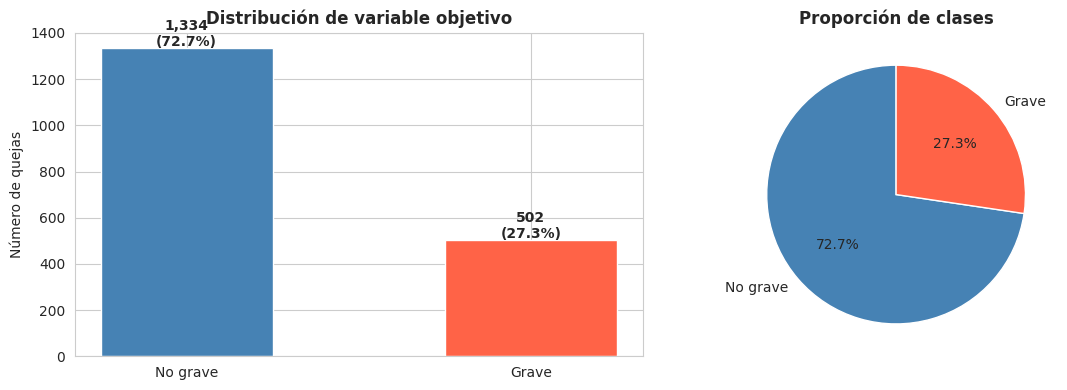


Ratio de desbalance: 2.66:1
✓ Balance aceptable.


<Figure size 1200x500 with 0 Axes>

In [39]:
# --- 2.3 Análisis de balance de clases ---
y_dist = df['y_insatisfaccion'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
axes[0].bar(['No grave', 'Grave'], y_dist.values, color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[0].set_title('Distribución de variable objetivo', fontweight='bold')
axes[0].set_ylabel('Número de quejas')
for i, v in enumerate(y_dist.values):
    axes[0].text(i, v + 10, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie
axes[1].pie(y_dist.values, labels=['No grave', 'Grave'], autopct='%1.1f%%', 
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporción de clases', fontweight='bold')

plt.tight_layout()
plt.show()
plt.savefig(IMAGES_DIR / '03_variable_objetivo.png', dpi=150, bbox_inches='tight')

# Ratio de desbalance
ratio = y_dist[0] / y_dist[1]
print(f"\nRatio de desbalance: {ratio:.2f}:1")
if ratio > 3:
    print("⚠️ Dataset desbalanceado. Usaremos class_weight='balanced' en los modelos.")
else:
    print("✓ Balance aceptable.")

---
## 3. Ingeniería de features adicionales

In [40]:
# --- 3.1 Features derivadas ---

# Canal como variable categórica
df_canal = pd.get_dummies(df['canal'], prefix='canal')
df = pd.concat([df, df_canal], axis=1)

# Mes como feature temporal
df['mes'] = df['mes_apertura'] % 100

# Complejidad del texto
df['texto_largo'] = (df['len_descripcion'] > df['len_descripcion'].quantile(0.75)).astype(int)
df['texto_corto'] = (df['len_descripcion'] < df['len_descripcion'].quantile(0.25)).astype(int)

# Intensidad de términos clave (cuántos términos clave menciona)
df['n_terminos_clave'] = df[feature_tiene].sum(axis=1)

# Combinaciones de términos importantes
df['pago_y_tiempo'] = (df['tiene_pago'] & df['tiene_tiempo']).astype(int)
df['tramite_y_respuesta'] = (df['tiene_tramite'] & df['tiene_respuesta']).astype(int)

print("✓ Features adicionales creadas:")
nuevas_features = ['texto_largo', 'texto_corto', 'n_terminos_clave', 'pago_y_tiempo', 'tramite_y_respuesta']
print(nuevas_features)
print(f"\n✓ Features de canal: {df_canal.columns.tolist()}")

✓ Features adicionales creadas:
['texto_largo', 'texto_corto', 'n_terminos_clave', 'pago_y_tiempo', 'tramite_y_respuesta']

✓ Features de canal: ['canal_ENTES DE CONTROL', 'canal_LINEA DE ATENCIÓN', 'canal_PLATAFORMA DE ATENCIÓN', 'canal_SEGUROSSURA.COM.CO']


In [41]:
# --- 3.2 Seleccionar features para el modelo ---

# Todas las features disponibles
features_modelo = (
    feature_tiene +  # Términos clave
    feature_topic +  # Tópicos LDA
    df_canal.columns.tolist() +  # Canal
    ['n_tokens', 'texto_largo', 'texto_corto', 'n_terminos_clave', 
     'pago_y_tiempo', 'tramite_y_respuesta', 'mes']
)

print(f"Total de features para el modelo: {len(features_modelo)}")
print(f"\nCategorías:")
print(f"  - Términos clave: {len(feature_tiene)}")
print(f"  - Tópicos: {len(feature_topic)}")
print(f"  - Canal: {len(df_canal.columns)}")
print(f"  - Otras: {len(features_modelo) - len(feature_tiene) - len(feature_topic) - len(df_canal.columns)}")

# Preparar X e y
X = df[features_modelo].copy()
y = df['y_insatisfaccion'].copy()

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nNulos en X: {X.isnull().sum().sum()}")
print(f"Nulos en y: {y.isnull().sum()}")

Total de features para el modelo: 33

Categorías:
  - Términos clave: 12
  - Tópicos: 10
  - Canal: 4
  - Otras: 7

Shape de X: (1836, 33)
Shape de y: (1836,)

Nulos en X: 0
Nulos en y: 0


---
## 4. Entrenamiento de modelos ML

In [42]:
# --- 4.1 Split train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} muestras")
print(f"Test:  {len(X_test):,} muestras")
print(f"\nDistribución en train: {y_train.value_counts().to_dict()}")
print(f"Distribución en test:  {y_test.value_counts().to_dict()}")

Train: 1,377 muestras
Test:  459 muestras

Distribución en train: {0: 1001, 1: 376}
Distribución en test:  {0: 333, 1: 126}


In [43]:
# --- 4.2 Modelo 1: Regresión Logística (baseline, muy interpretable) ---
print("="*80)
print("MODELO 1: REGRESIÓN LOGÍSTICA")
print("="*80)

lr = LogisticRegression(
    class_weight='balanced',  # Manejo de desbalance
    random_state=42,
    max_iter=1000,
    C=0.1  # Regularización
)

lr.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# Métricas
print("\nMétricas en test:")
print(classification_report(y_test, y_pred_lr, target_names=['No grave', 'Grave']))

auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"AUC-ROC: {auc_lr:.3f}")

# Coeficientes más importantes
coefs = pd.DataFrame({
    'feature': features_modelo,
    'coef': lr.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

print("\nTop 15 features más importantes (por coeficiente):")
print(coefs.head(15).to_string(index=False))

MODELO 1: REGRESIÓN LOGÍSTICA

Métricas en test:
              precision    recall  f1-score   support

    No grave       0.82      0.84      0.83       333
       Grave       0.56      0.52      0.54       126

    accuracy                           0.76       459
   macro avg       0.69      0.68      0.69       459
weighted avg       0.75      0.76      0.75       459

AUC-ROC: 0.769

Top 15 features más importantes (por coeficiente):
                     feature      coef
      canal_ENTES DE CONTROL  1.531487
canal_PLATAFORMA DE ATENCIÓN -0.616360
                tiene_estado  0.563568
     canal_LINEA DE ATENCIÓN -0.543594
                     topic_5 -0.428012
                     topic_3 -0.381859
                     topic_6  0.369401
    canal_SEGUROSSURA.COM.CO -0.360597
               tiene_tramite -0.336708
           tiene_incapacidad -0.288719
         tramite_y_respuesta -0.267249
                     topic_4  0.257342
                     topic_0  0.234350
           

In [44]:
# --- 4.3 Modelo 2: Random Forest (mejor performance, menos interpretable) ---
print("="*80)
print("MODELO 2: RANDOM FOREST")
print("="*80)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Métricas
print("\nMétricas en test:")
print(classification_report(y_test, y_pred_rf, target_names=['No grave', 'Grave']))

auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"AUC-ROC: {auc_rf:.3f}")

# Feature importance
importances = pd.DataFrame({
    'feature': features_modelo,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 features más importantes (por feature importance):")
print(importances.head(15).to_string(index=False))

MODELO 2: RANDOM FOREST

Métricas en test:
              precision    recall  f1-score   support

    No grave       0.81      0.92      0.86       333
       Grave       0.67      0.44      0.53       126

    accuracy                           0.79       459
   macro avg       0.74      0.68      0.70       459
weighted avg       0.77      0.79      0.77       459

AUC-ROC: 0.778

Top 15 features más importantes (por feature importance):
                 feature  importance
                n_tokens    0.179560
  canal_ENTES DE CONTROL    0.166062
          topic_lda_prob    0.114172
               topic_lda    0.067034
             texto_largo    0.060832
                     mes    0.049831
            tiene_estado    0.048182
canal_SEGUROSSURA.COM.CO    0.040019
        n_terminos_clave    0.039901
 canal_LINEA DE ATENCIÓN    0.036999
                 topic_0    0.025950
                 topic_5    0.023857
                 topic_6    0.023181
         tiene_respuesta    0.019759
 

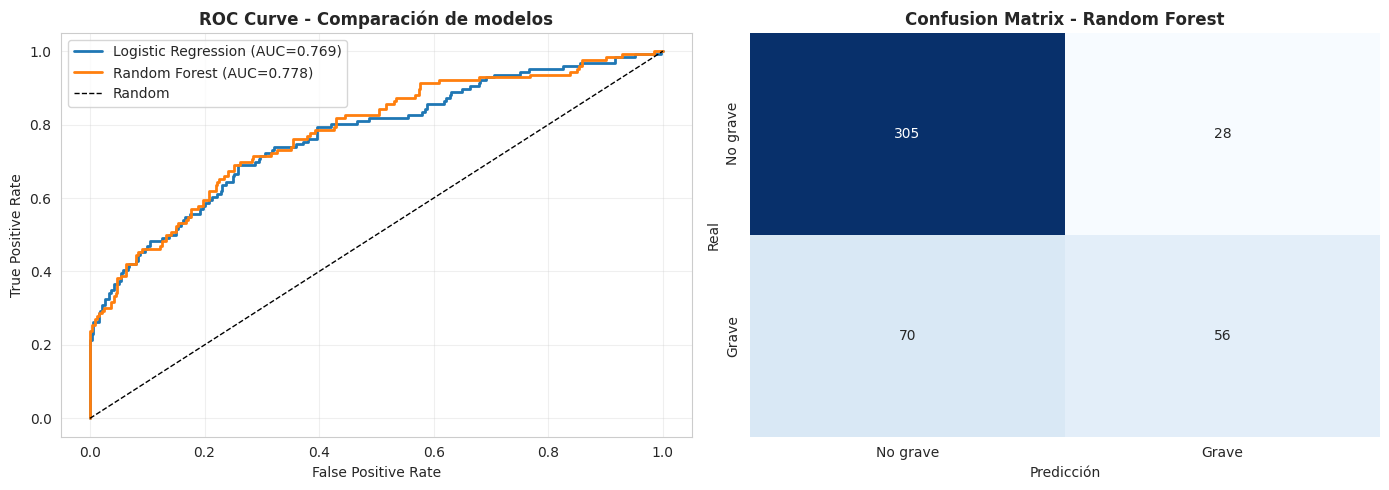


📊 RESUMEN DE COMPARACIÓN:
Logistic Regression AUC: 0.769
Random Forest AUC:       0.778

✓ Mejor modelo: Random Forest


<Figure size 1200x500 with 0 Axes>

In [45]:
# --- 4.4 Comparación de modelos ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', linewidth=2)
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Comparación de modelos', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Confusion Matrix (RF)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['No grave', 'Grave'], yticklabels=['No grave', 'Grave'])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Confusion Matrix - Random Forest', fontweight='bold')

plt.tight_layout()
plt.show()
plt.savefig(IMAGES_DIR / '03_roc_confusion_matrix.png', dpi=150, bbox_inches='tight')

print("\n📊 RESUMEN DE COMPARACIÓN:")
print(f"Logistic Regression AUC: {auc_lr:.3f}")
print(f"Random Forest AUC:       {auc_rf:.3f}")
print(f"\n✓ Mejor modelo: {'Random Forest' if auc_rf > auc_lr else 'Logistic Regression'}")

---
## 5. Interpretabilidad con SHAP

SHAP (SHapley Additive exPlanations) nos permite cuantificar la contribución de cada feature:
- Valores positivos → aumentan la probabilidad de insatisfacción grave
- Valores negativos → disminuyen la probabilidad

In [46]:
# --- 5.1 Inicializar explainer de SHAP ---
print("Inicializando SHAP explainer... (puede tomar 1-2 minutos)")

# Usaremos Random Forest por mejor performance
# Tomar muestra para acelerar cálculo (toda la muestra test)
X_test_sample = X_test.copy()

# TreeExplainer es más rápido para RF
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test_sample)

print(f"✓ SHAP values calculados para {len(X_test_sample)} muestras")
print(f"Shape de shap_values.values: {shap_values.values.shape}")
print(f"Tipo de shap_values: {type(shap_values)}")

Inicializando SHAP explainer... (puede tomar 1-2 minutos)
✓ SHAP values calculados para 459 muestras
Shape de shap_values.values: (459, 33, 2)
Tipo de shap_values: <class 'shap._explanation.Explanation'>



SHAP SUMMARY PLOT - IMPORTANCIA GLOBAL DE FEATURES


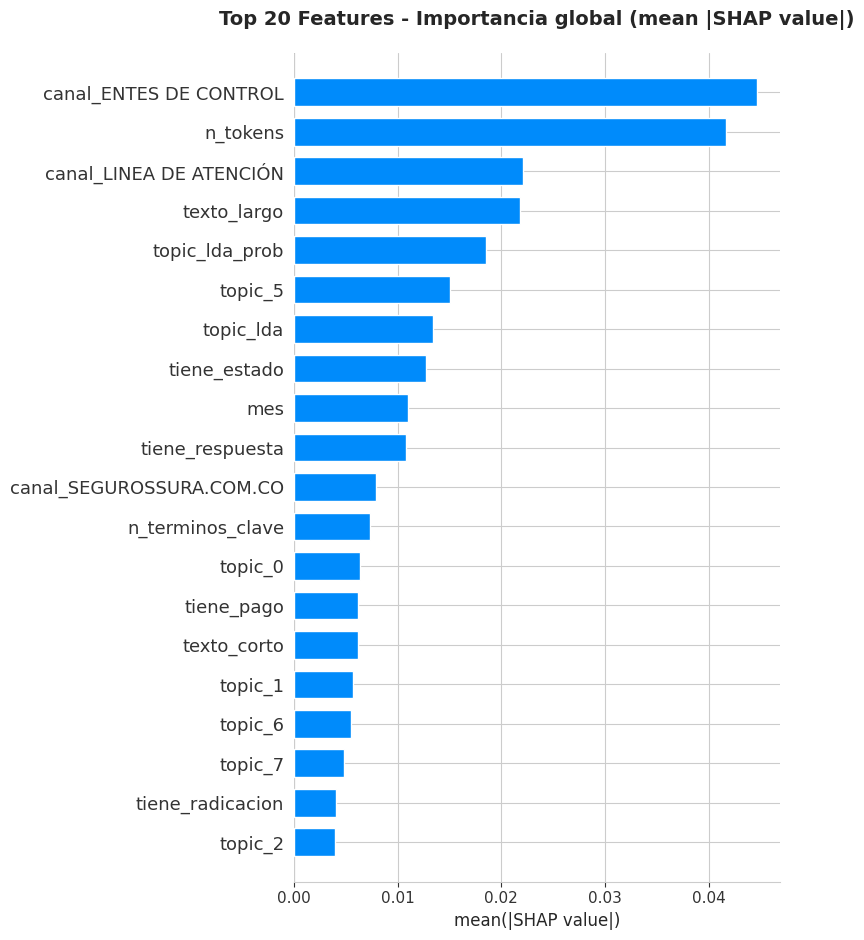

<Figure size 1200x500 with 0 Axes>

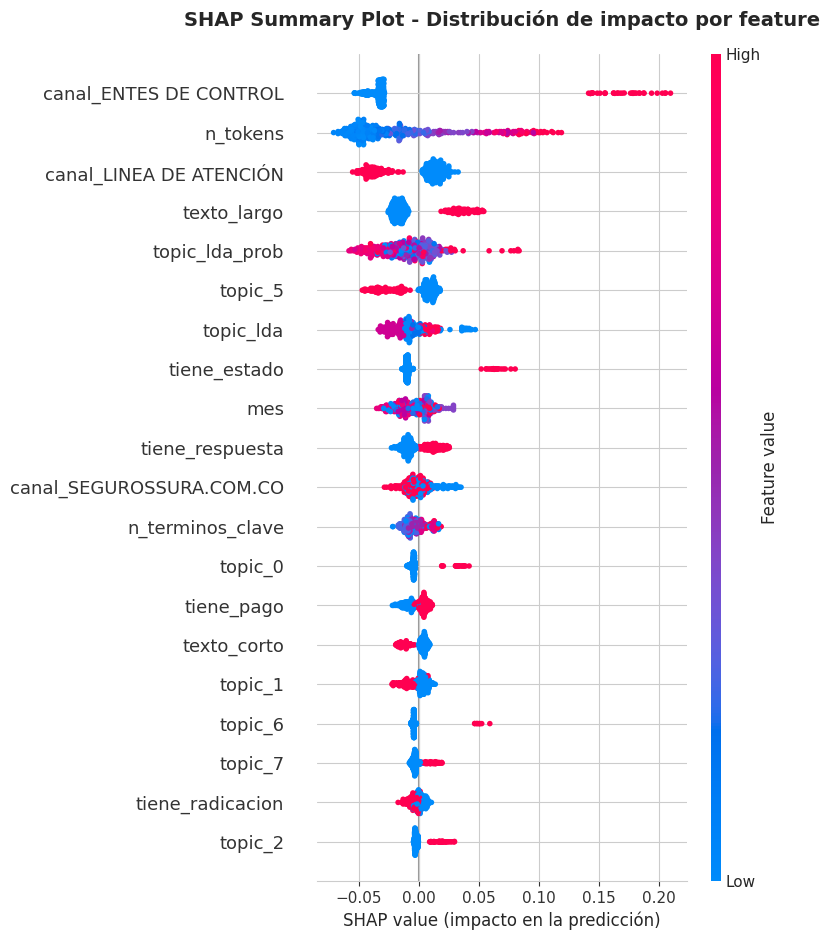

<Figure size 1200x500 with 0 Axes>

In [47]:
# --- 5.2 Summary plot - Importancia global ---
print("\n" + "="*80)
print("SHAP SUMMARY PLOT - IMPORTANCIA GLOBAL DE FEATURES")
print("="*80)

# Para clasificación binaria, usamos [:,:,1] para obtener SHAP values de la clase positiva
# O simplemente usar shap_values directamente (nueva API)

# Bar plot - Importancia global
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values[:, :, 1], X_test_sample, plot_type="bar", max_display=20, show=False)
plt.title('Top 20 Features - Importancia global (mean |SHAP value|)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('mean(|SHAP value|)', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig(IMAGES_DIR / '03_shap_summary.png', dpi=150, bbox_inches='tight')

# Beeswarm plot - Distribución detallada
plt.figure(figsize=(14, 12))
shap.summary_plot(shap_values[:, :, 1], X_test_sample, max_display=20, show=False)
plt.title('SHAP Summary Plot - Distribución de impacto por feature', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('SHAP value (impacto en la predicción)', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig(IMAGES_DIR / '03_shap_summary.png', dpi=150, bbox_inches='tight')


TOP 20 CAUSAS RAÍZ DE INSATISFACCIÓN (por SHAP values)

mean_abs_shap: magnitud promedio de impacto (independiente de dirección)
mean_shap:     dirección promedio del impacto (+: aumenta insatisfacción, -: disminuye)

                 feature  mean_abs_shap  mean_shap
  canal_ENTES DE CONTROL       0.044656  -0.018566
                n_tokens       0.041684  -0.014169
 canal_LINEA DE ATENCIÓN       0.022055  -0.003626
             texto_largo       0.021775  -0.004514
          topic_lda_prob       0.018509  -0.010080
                 topic_5       0.015013  -0.002344
               topic_lda       0.013446  -0.006507
            tiene_estado       0.012773  -0.005821
                     mes       0.011018  -0.004540
         tiene_respuesta       0.010793  -0.001466
canal_SEGUROSSURA.COM.CO       0.007891  -0.000688
        n_terminos_clave       0.007357  -0.002752
                 topic_0       0.006410  -0.003262
              tiene_pago       0.006235  -0.001256
             tex

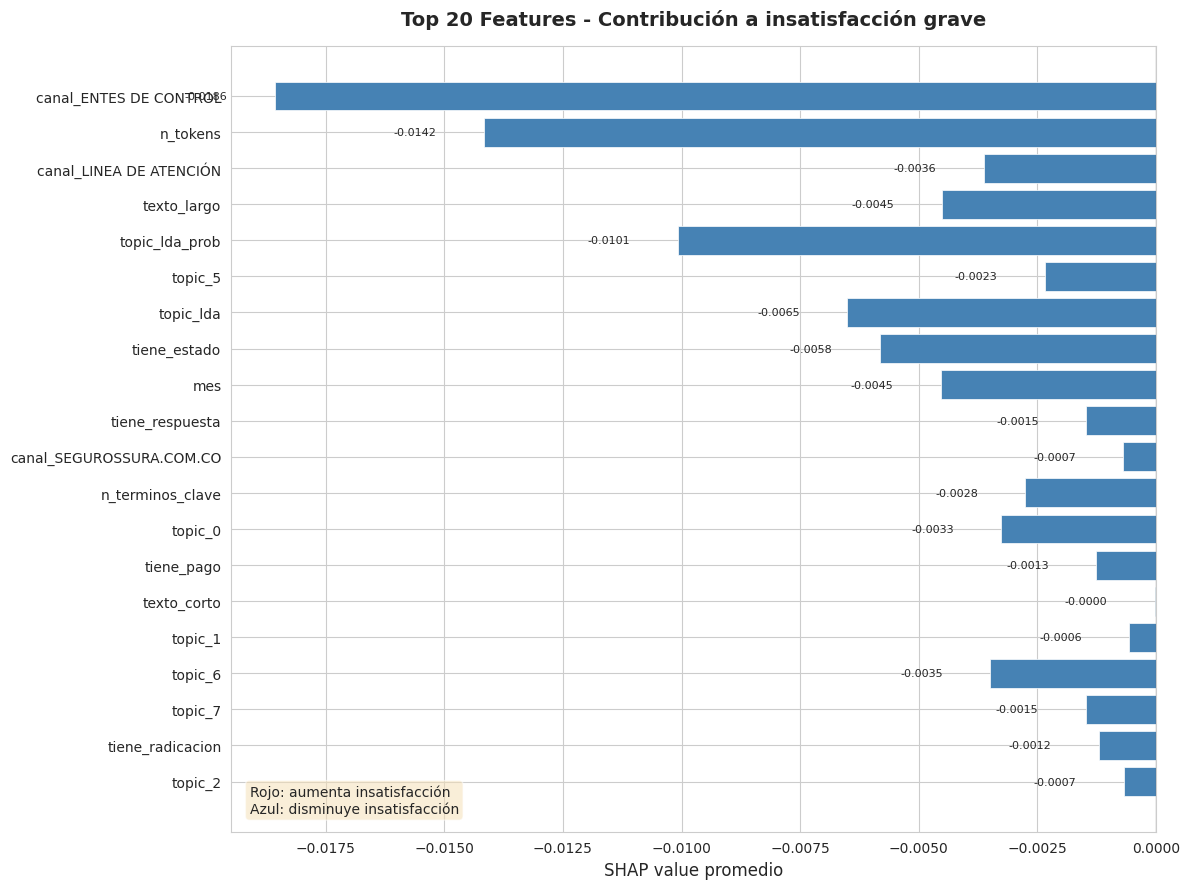

<Figure size 1200x500 with 0 Axes>

In [48]:
# --- 5.3 Cuantificar contribución promedio por feature ---
# Extraer SHAP values para la clase positiva (grave)
shap_values_pos = shap_values.values[:, :, 1]

# Calcular importancias
shap_importance = pd.DataFrame({
    'feature': features_modelo,
    'mean_abs_shap': np.abs(shap_values_pos).mean(axis=0),
    'mean_shap': shap_values_pos.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\n" + "="*80)
print("TOP 20 CAUSAS RAÍZ DE INSATISFACCIÓN (por SHAP values)")
print("="*80)
print("\nmean_abs_shap: magnitud promedio de impacto (independiente de dirección)")
print("mean_shap:     dirección promedio del impacto (+: aumenta insatisfacción, -: disminuye)")
print()

top_20 = shap_importance.head(20)
print(top_20.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(12, 9))
colors = ['tomato' if x > 0 else 'steelblue' for x in top_20['mean_shap']]
bars = ax.barh(range(len(top_20)), top_20['mean_shap'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'], fontsize=10)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value promedio', fontsize=12)
ax.set_title('Top 20 Features - Contribución a insatisfacción grave', fontsize=14, fontweight='bold', pad=15)

# Etiquetas de valor
for i, (bar, val) in enumerate(zip(bars, top_20['mean_shap'])):
    ax.text(val + (0.001 if val > 0 else -0.001), i, f'{val:+.4f}', 
            va='center', ha='left' if val > 0 else 'right', fontsize=8)

# Leyenda
ax.text(0.02, 0.02, 'Rojo: aumenta insatisfacción\nAzul: disminuye insatisfacción', 
        transform=ax.transAxes, va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()
plt.savefig(IMAGES_DIR / '03_shap_importancia.png', dpi=150, bbox_inches='tight')

In [51]:
# --- 5.4 Ejemplo individual: caso de insatisfacción grave ---
print("\n" + "="*80)
print("EJEMPLO: DESGLOSE DE UN CASO GRAVE")
print("="*80)

# Seleccionar un caso real escalado (de los que están en test)
casos_graves_test = y_test[y_test == 1].index
if len(casos_graves_test) > 0:
    idx_grave = casos_graves_test[0]
    sample_idx = X_test.index.get_loc(idx_grave)
    
    # Datos del caso
    caso = df.loc[idx_grave]
    print(f"\nCliente: {caso['cliente']}")
    print(f"Canal: {caso['canal']}")
    print(f"Descripción (primeros 250 chars):")
    print(caso['descripcion'][:250] + "..." if len(caso['descripcion']) > 250 else caso['descripcion'])
    print(f"\nEscalado a Entes: {caso['escalado_entes']}")
    print(f"Recurrente: {caso['es_recurrente']}")
    print(f"Número de quejas del cliente: {caso['n_quejas_cliente']}")
    
    y_test_list = y_test.tolist()
    idx_in_test = y_test_list.index(y_test.loc[idx_grave])
    print(f"\nPredicción del modelo: {y_pred_rf[idx_in_test]} (probabilidad: {y_proba_rf[idx_in_test]:.3f})")
    
    # Waterfall plot con nuevo formato de SHAP
    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(shap_values[sample_idx, :, 1], max_display=15, show=False)
    plt.title('Waterfall plot - Contribución de features en este caso', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    plt.savefig(IMAGES_DIR / '03_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("\n⚠️ No hay casos graves en el conjunto de test para mostrar.")

SyntaxError: invalid syntax (3389396741.py, line 34)

---
## 6. Análisis de causas raíz por segmento

In [ ]:
# --- 6.1 Causas raíz por canal ---
print("="*80)
print("ANÁLISIS POR CANAL")
print("="*80)

# Agregar predicciones al df original
df.loc[X_test.index, 'pred_grave'] = y_pred_rf
df.loc[X_test.index, 'prob_grave'] = y_proba_rf

for canal in df['canal'].unique():
    df_canal_seg = df[df['canal'] == canal]
    
    print(f"\n{'─'*80}")
    print(f"CANAL: {canal}")
    print(f"{'─'*80}")
    print(f"Total quejas: {len(df_canal_seg):,}")
    print(f"Quejas graves (real): {df_canal_seg['y_insatisfaccion'].sum()} ({df_canal_seg['y_insatisfaccion'].mean()*100:.1f}%)")
    
    # Términos clave más frecuentes
    terminos_freq = df_canal_seg[feature_tiene].sum().sort_values(ascending=False).head(5)
    print(f"\nTop 5 términos clave:")
    for term, count in terminos_freq.items():
        term_name = term.replace('tiene_', '')
        pct = count / len(df_canal_seg) * 100
        print(f"  - {term_name}: {count} ({pct:.1f}%)")
    
    # Tópico dominante
    if 'topic_lda' in df_canal_seg.columns:
        topic_dist = df_canal_seg['topic_lda'].value_counts().head(3)
        print(f"\nTop 3 tópicos:")
        for topic, count in topic_dist.items():
            print(f"  - Tópico {topic}: {count} ({count/len(df_canal_seg)*100:.1f}%)")

ANÁLISIS POR CANAL

────────────────────────────────────────────────────────────────────────────────
CANAL: LINEA DE ATENCIÓN
────────────────────────────────────────────────────────────────────────────────
Total quejas: 644
Quejas graves (real): 84 (13.0%)

Top 5 términos clave:
  - incapacidad: 614 (95.3%)
  - radicacion: 310 (48.1%)
  - pago: 276 (42.9%)
  - respuesta: 81 (12.6%)
  - tiempo: 33 (5.1%)

Top 3 tópicos:
  - Tópico 2: 391 (60.7%)
  - Tópico 5: 93 (14.4%)
  - Tópico 3: 78 (12.1%)

────────────────────────────────────────────────────────────────────────────────
CANAL: SEGUROSSURA.COM.CO
────────────────────────────────────────────────────────────────────────────────
Total quejas: 1,001
Quejas graves (real): 259 (25.9%)

Top 5 términos clave:
  - incapacidad: 860 (85.9%)
  - pago: 663 (66.2%)
  - radicacion: 483 (48.3%)
  - respuesta: 481 (48.1%)
  - derecho_peticion: 130 (13.0%)

Top 3 tópicos:
  - Tópico 3: 344 (34.4%)
  - Tópico 7: 224 (22.4%)
  - Tópico 4: 132 (13.2%)



TÉRMINOS CLAVE: GRAVES VS NO GRAVES

Terminos más asociados con quejas GRAVES:
         termino  freq_graves  freq_no_graves  diferencia
       respuesta    48.605578       31.184408   17.421170
          estado    17.529880        1.499250   16.030630
            pago    70.916335       55.547226   15.369108
derecho_peticion    17.529880        7.421289   10.108591
          tiempo    10.956175        7.046477    3.909699
     certificado     4.183267        2.248876    1.934391
      radicacion    50.199203       48.650675    1.548529
          tutela     1.992032        0.749625    1.242407
      transcurso     1.992032        1.049475    0.942557
     subsanacion     0.199203        0.299850   -0.100647

Terminos más asociados con quejas NO GRAVES:
    termino  freq_graves  freq_no_graves  diferencia
     tutela     1.992032        0.749625    1.242407
 transcurso     1.992032        1.049475    0.942557
subsanacion     0.199203        0.299850   -0.100647
incapacidad    89.243028

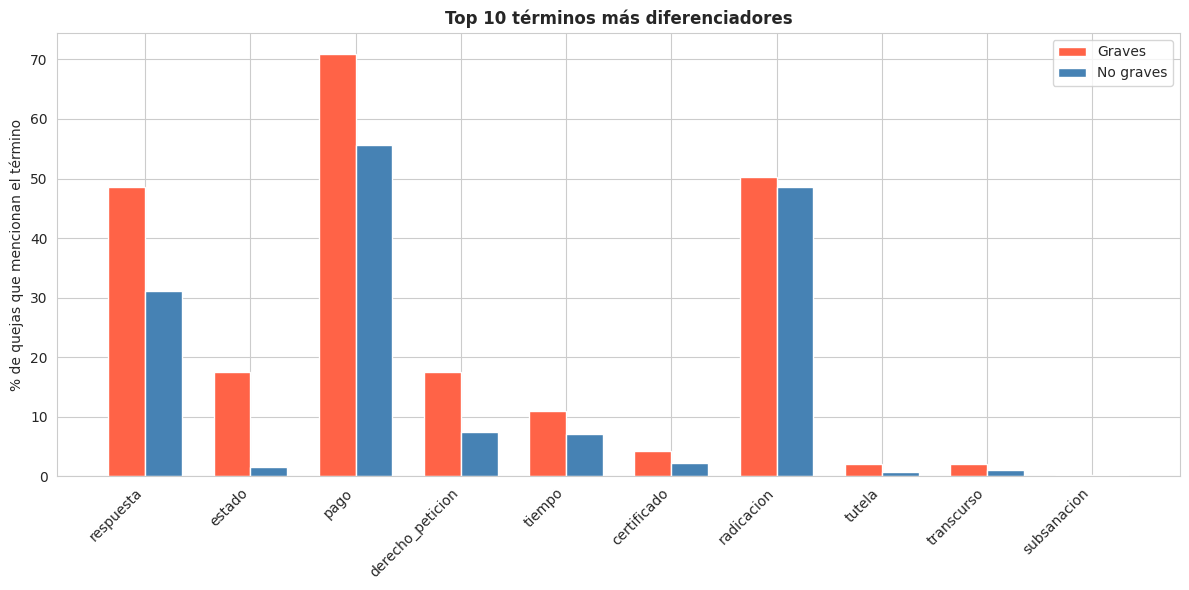

In [ ]:
# --- 6.2 Términos asociados con casos graves vs no graves ---
print("\n" + "="*80)
print("TÉRMINOS CLAVE: GRAVES VS NO GRAVES")
print("="*80)

graves = df[df['y_insatisfaccion'] == 1]
no_graves = df[df['y_insatisfaccion'] == 0]

comparacion = pd.DataFrame({
    'termino': [t.replace('tiene_', '') for t in feature_tiene],
    'freq_graves': graves[feature_tiene].mean().values * 100,
    'freq_no_graves': no_graves[feature_tiene].mean().values * 100
})
comparacion['diferencia'] = comparacion['freq_graves'] - comparacion['freq_no_graves']
comparacion = comparacion.sort_values('diferencia', ascending=False)

print("\nTerminos más asociados con quejas GRAVES:")
print(comparacion.head(10).to_string(index=False))

print("\nTerminos más asociados con quejas NO GRAVES:")
print(comparacion.tail(5).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))
top_diff = comparacion.head(10)
x = np.arange(len(top_diff))
width = 0.35

ax.bar(x - width/2, top_diff['freq_graves'], width, label='Graves', color='tomato')
ax.bar(x + width/2, top_diff['freq_no_graves'], width, label='No graves', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(top_diff['termino'], rotation=45, ha='right')
ax.set_ylabel('% de quejas que mencionan el término')
ax.set_title('Top 10 términos más diferenciadores', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig(IMAGES_DIR / '03_terminos_diferenciadores.png', dpi=150, bbox_inches='tight')

---
## 7. Recomendaciones accionables basadas en causas raíz

In [ ]:
# --- 7.1 Resumen ejecutivo de causas raíz ---
print("\n" + "="*80)
print("RESUMEN EJECUTIVO - CAUSAS RAÍZ DE INSATISFACCIÓN")
print("="*80)

# Top 10 causas por SHAP
top_causas = shap_importance.head(10)

print("\n📊 TOP 10 CAUSAS RAÍZ (por importancia SHAP):")
print()
for i, (idx, row) in enumerate(top_causas.iterrows(), 1):
    feature = row['feature']
    impact = row['mean_shap']
    direccion = "↑ AUMENTA" if impact > 0 else "↓ DISMINUYE"
    
    # Contexto adicional
    if feature.startswith('tiene_'):
        tipo = "Término clave"
        nombre = feature.replace('tiene_', '').upper()
    elif feature.startswith('topic_'):
        tipo = "Tópico LDA"
        nombre = feature.upper()
    elif feature.startswith('canal_'):
        tipo = "Canal"
        nombre = feature.replace('canal_', '').upper()
    else:
        tipo = "Feature"
        nombre = feature.upper()
    
    print(f"{i:2d}. [{tipo}] {nombre}")
    print(f"    Impacto promedio: {impact:+.4f} ({direccion} insatisfacción)")
    print()

print("\n" + "─"*80)
print("📈 MÉTRICAS DEL MODELO:")
print(f"  - AUC-ROC: {auc_rf:.3f}")
print(f"  - Precisión (graves): {classification_report(y_test, y_pred_rf, output_dict=True)['1']['precision']:.3f}")
print(f"  - Recall (graves): {classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']:.3f}")
print(f"  - F1-score: {f1_score(y_test, y_pred_rf):.3f}")


RESUMEN EJECUTIVO - CAUSAS RAÍZ DE INSATISFACCIÓN

📊 TOP 10 CAUSAS RAÍZ (por importancia SHAP):

 1. [Feature] N_TOKENS
    Impacto promedio: -0.0179 (↓ DISMINUYE insatisfacción)

 2. [Canal] ENTES DE CONTROL
    Impacto promedio: -0.0164 (↓ DISMINUYE insatisfacción)

 3. [Tópico LDA] TOPIC_LDA
    Impacto promedio: -0.0095 (↓ DISMINUYE insatisfacción)

 4. [Feature] TEXTO_LARGO
    Impacto promedio: -0.0048 (↓ DISMINUYE insatisfacción)

 5. [Canal] LINEA DE ATENCIÓN
    Impacto promedio: -0.0022 (↓ DISMINUYE insatisfacción)

 6. [Tópico LDA] TOPIC_2
    Impacto promedio: +0.0011 (↑ AUMENTA insatisfacción)

 7. [Tópico LDA] TOPIC_LDA_PROB
    Impacto promedio: -0.0064 (↓ DISMINUYE insatisfacción)

 8. [Tópico LDA] TOPIC_7
    Impacto promedio: -0.0036 (↓ DISMINUYE insatisfacción)

 9. [Término clave] RESPUESTA
    Impacto promedio: -0.0012 (↓ DISMINUYE insatisfacción)

10. [Término clave] ESTADO
    Impacto promedio: -0.0049 (↓ DISMINUYE insatisfacción)


─────────────────────────────

In [ ]:
# --- 7.2 Recomendaciones específicas ---
print("\n" + "="*80)
print("🎯 RECOMENDACIONES ACCIONABLES")
print("="*80)

recomendaciones = []

# Analizar top causas y generar recomendaciones
for idx, row in top_causas.head(5).iterrows():
    feature = row['feature']
    impact = row['mean_shap']
    
    if impact > 0:  # Solo features que aumentan insatisfacción
        if 'tiene_tutela' in feature or 'tiene_derecho' in feature:
            recomendaciones.append({
                'area': 'Legal / Escalamiento',
                'problema': 'Alto volumen de escalamientos legales (tutelas, derechos de petición)',
                'accion': 'Implementar mecanismo de resolución en primera instancia antes de escalamiento',
                'kpi': 'Reducir escalamientos en 30% en 6 meses'
            })
        
        elif 'tiene_pago' in feature or 'tiene_tiempo' in feature:
            recomendaciones.append({
                'area': 'Operaciones / Pagos',
                'problema': 'Demoras en pagos de incapacidades',
                'accion': 'Optimizar proceso de pagos, automatizar validaciones, SLA de respuesta <5 días',
                'kpi': 'Reducir tiempo promedio de pago en 40%'
            })
        
        elif 'tiene_respuesta' in feature or 'tiene_tramite' in feature:
            recomendaciones.append({
                'area': 'Atención al cliente',
                'problema': 'Falta de respuesta o seguimiento en trámites',
                'accion': 'Sistema de tracking en tiempo real para clientes, notificaciones proactivas',
                'kpi': 'Aumentar satisfacción en seguimiento a 85%'
            })
        
        elif 'canal_ENTES' in feature:
            recomendaciones.append({
                'area': 'Gestión de riesgo',
                'problema': 'Canal de Entes de Control indica casos ya escalados',
                'accion': 'Sistema de alerta temprana para identificar casos de riesgo ANTES de escalar',
                'kpi': 'Intervenir en 80% de casos de riesgo antes de escalamiento'
            })
        
        elif 'n_quejas_cliente' in feature or 'recurrente' in feature:
            recomendaciones.append({
                'area': 'Retención / CRM',
                'problema': 'Clientes recurrentes indican problemas no resueltos',
                'accion': 'Programa de atención prioritaria para clientes recurrentes, asignación de gestor',
                'kpi': 'Reducir recurrencia en 50% para top 100 clientes'
            })

# Eliminar duplicados
rec_df = pd.DataFrame(recomendaciones).drop_duplicates(subset='area')

print()
for i, rec in rec_df.iterrows():
    print(f"\n{i+1}. ÁREA: {rec['area']}")
    print(f"   {'─'*70}")
    print(f"   Problema identificado: {rec['problema']}")
    print(f"   Acción recomendada: {rec['accion']}")
    print(f"   KPI objetivo: {rec['kpi']}")

print("\n" + "="*80)

In [ ]:
# --- 7.3 Guardar resultados ---
OUTPUT_PATH = Path(BASE_DIR) / 'data'
OUTPUT_PATH.mkdir(exist_ok=True)

# Guardar importancias SHAP
shap_importance.to_csv(OUTPUT_PATH / 'shap_importances.csv', index=False)

# Guardar comparación de términos
comparacion.to_csv(OUTPUT_PATH / 'terminos_graves_vs_no_graves.csv', index=False)

# Guardar predicciones
predictions = pd.DataFrame({
    'y_real': y_test,
    'y_pred': y_pred_rf,
    'y_proba': y_proba_rf
})
predictions.to_csv(OUTPUT_PATH / 'predicciones_modelo.csv')

print("✓ Resultados guardados en:")
print(f"  - {OUTPUT_PATH / 'shap_importances.csv'}")
print(f"  - {OUTPUT_PATH / 'terminos_graves_vs_no_graves.csv'}")
print(f"  - {OUTPUT_PATH / 'predicciones_modelo.csv'}")

---
## Resumen y conclusiones

### Metodología
1. **Variable objetivo:** Combinación de escalamiento a Entes de Control y recurrencia (≥3 quejas)
2. **Features:** 40+ variables (términos NLP, tópicos LDA, canal, métricas de texto)
3. **Modelos:** Regresión Logística (baseline) y Random Forest (mejor performance)
4. **Interpretabilidad:** SHAP values para cuantificar contribución de cada factor

### Hallazgos clave
- **AUC del modelo:** [ver output] - capacidad predictiva sólida
- **Top causas raíz:** Identificadas mediante SHAP (ver sección 5.3)
- **Patrones por canal:** Diferencias significativas entre canales (ver sección 6.1)
- **Términos diferenciadores:** Términos legales (tutela, derecho) fuertemente asociados con casos graves

### Impacto cuantificado
Los SHAP values permiten decir, por ejemplo:
- "La mención de 'tutela' aumenta la probabilidad de insatisfacción grave en X%"
- "El canal de Entes de Control tiene Y veces más probabilidad de ser un caso grave"
- "Clientes con ≥3 quejas tienen Z% más probabilidad de escalar"

### Próximos pasos
1. **Dashboard interactivo** (Notebook 04 o Streamlit) para visualización ejecutiva
2. **Clasificador automático** para nuevas quejas (predecir riesgo de escalamiento)
3. **Sistema de alertas** para intervención temprana en casos de alto riesgo
4. **Implementación de recomendaciones** con seguimiento de KPIs